In [18]:
import math
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

torch.manual_seed(0)

device: cpu


Dans ce notebook, on fait un premier test avec le sample détaillé dans l'overleaf pour voir ce que ça donne. Le réseau est entrainé à prédire le bruit ajouté à $Z_0$, ce qui donne $Z_t$ au temps t.

Génération de données synthétiques

In [34]:
mu_x0 = 3.0
var_x0 = 0.4
sigma_base = 0.04
eps_base=3
var_z0 = var_x0 + sigma_base**2  # 4.4


n_samples = 30000
eps_mean = 3.0/sigma_base

data = "gaussian"  # "gaussian" or "mixture"

mu_z0 = mu_x0 + sigma_base * eps_mean
var_z0 = var_x0 + sigma_base**2
# Mixture parameters for X_0
mixture_weights = torch.tensor([0.5, 0.5], device=device)
mixture_means = torch.tensor([1, 5.0], device=device)
mixture_stds = torch.tensor([0.4, 0.4], device=device)


def sample_x0_mixture(batch_size):
    """
    Sample hidden clean latent X_0 from a 1D Gaussian mixture.

        X_0 ~ sum_k pi_k N(mu_k, std_k^2)
    """

    # sample component indices
    comp_ids = torch.multinomial(
        mixture_weights,
        num_samples=batch_size,
        replacement=True
    )

   
    means = mixture_means[comp_ids].reshape(batch_size, 1)
    stds = mixture_stds[comp_ids].reshape(batch_size, 1)

    # sample from selected Gaussian component
    x0 = means + stds * torch.randn(batch_size, 1, device=device)

    return x0

def sample_x0(batch_size, mu_x=3.0, var_x=0.4):
    std_x = torch.sqrt(torch.tensor(var_x, device=device))
    x0 = mu_x + std_x * torch.randn(batch_size, 1, device=device)
    return x0


def sample_z0_from_x0(x0):
    """
    Observation model:
    
        Z_0 = X_0 + sigma * eps_0
    """
    eps0 = eps_mean +  torch.randn_like(x0)
    z0 = x0 + sigma_base *eps0
    return z0


def sample_joint_data(batch_size, data):
    """
    Return both hidden X_0 and observed Z_0.
    """
    if data == 'mixture':
        x0 = sample_x0_mixture(batch_size)
    else:
        x0 = sample_x0(batch_size, mu_x=3.0, var_x=0.4)
    z0 = sample_z0_from_x0(x0)
    return x0, z0


def sample_data(batch_size, data=data):
    """
    The DDPM only observes Z_0.
    """
    _, z0 = sample_joint_data(batch_size, data=data)
    return z0

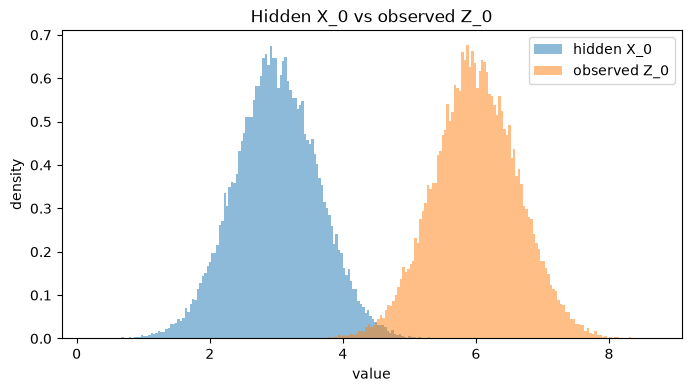

In [35]:
x0, z0 = sample_joint_data(n_samples, data=data)

x0_np = x0.detach().cpu().numpy()
z0_np = z0.detach().cpu().numpy()

plt.figure(figsize=(8, 4))
plt.hist(x0_np, bins=150, density=True, alpha=0.5, label="hidden X_0")
plt.hist(z0_np, bins=150, density=True, alpha=0.5, label="observed Z_0")
plt.title("Hidden X_0 vs observed Z_0")
plt.xlabel("value")
plt.ylabel("density")
plt.legend()
plt.show()

Hyperparamètre et noise schedule

In [36]:
T = 500

beta_start = 1e-4
beta_end = 0.04

betas = torch.linspace(beta_start, beta_end, T, device=device) # Schedule linéaire pour les betas
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

def sigma2_at_index(t_index):
    """
    Return sigma_t^2 = sigma_base^2 / 2^t for Python index t.
    t_index shape: (batch_size,)
    """
    return sigma_base**2 * torch.exp(-math.log(2.0) * t_index.float())


def extract_sigma2(t, x_shape):
    """
    Return sigma_t^2 reshaped for broadcasting.
    """
    out = sigma2_at_index(t)
    return out.reshape(-1, *([1] * (len(x_shape) - 1)))

def extract(v, t, x_shape):
    """
    Extract v[t] for each element of the batch, then reshape for broadcasting.

    v: tensor of shape (T,)
       Example: betas, alphas, alpha_bars

    t: tensor of shape (batch_size,)
       Time index for each sample in the batch.

    x_shape: shape of the variable we want to multiply with.
       Example: z.shape = (batch_size, 1)

    Returns:
       tensor of shape (batch_size, 1, ..., 1)
    """
    out = v.gather(0, t)
    return out.view(t.shape[0], *([1] * (len(x_shape) - 1)))

Forward

In [37]:
def q_sample(z0, t, eps=None):
    """
    Sample z_t from q(z_t | z_0).
    """
    if eps is None:
        eps = torch.randn_like(z0)

    alpha_bar_t = extract(alpha_bars, t, z0.shape)

    zt = torch.sqrt(alpha_bar_t) * z0 + torch.sqrt(1.0 - alpha_bar_t) * eps
    return zt, eps

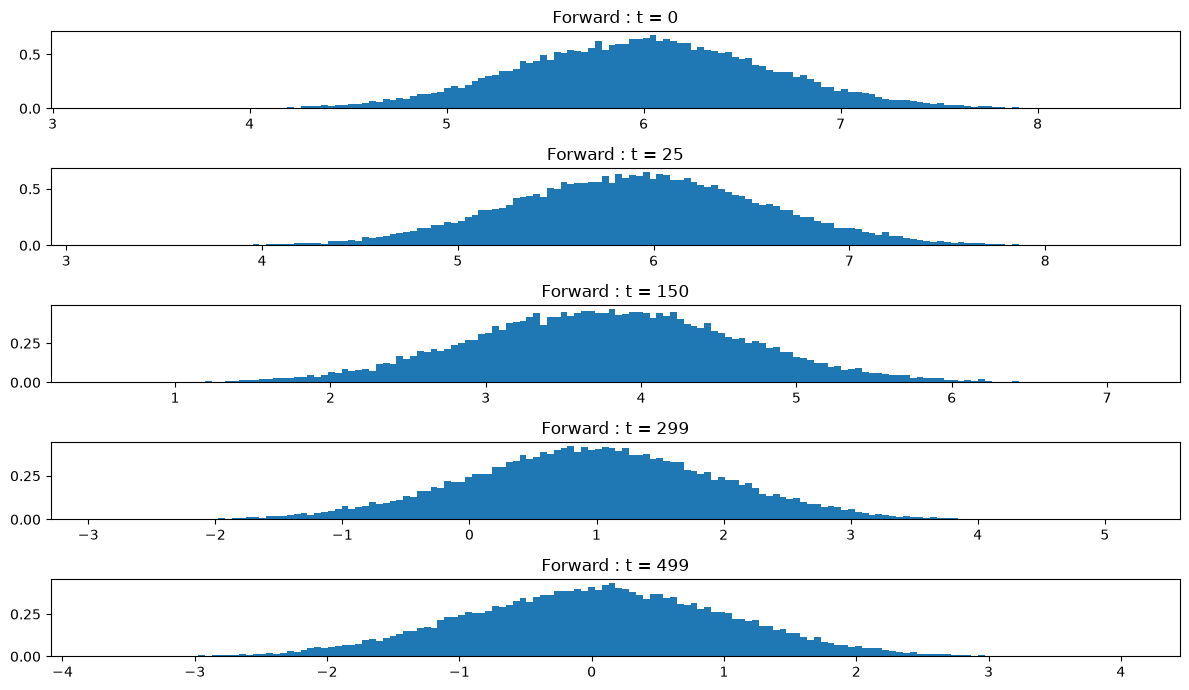

In [38]:
z0 = sample_data(30000, data=data)

times_to_plot = [0, 25, 150, 299, 499]

plt.figure(figsize=(12, 7))

for i, tt in enumerate(times_to_plot):
    t = torch.full((z0.shape[0],), tt, device=device, dtype=torch.long)
    zt, _ = q_sample(z0, t)
    zt_np = zt.detach().cpu().numpy()

    plt.subplot(len(times_to_plot), 1, i + 1)
    plt.hist(zt_np, bins=150, density=True)
    plt.title(f"Forward : t = {tt}")

plt.tight_layout()
plt.show()

Entrainement pour prédire le score

In [39]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        """
        t: shape (batch_size,)
        returns: shape (batch_size, dim)
        """
        half_dim = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half_dim, device=t.device) / (half_dim - 1)
        )
        args = t[:, None].float() * freqs[None, :]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))

        return emb


class ScoreModel(nn.Module):
    def __init__(self, time_dim=64, hidden_dim=128):
        super().__init__()

        self.time_embedding = SinusoidalTimeEmbedding(time_dim)

        self.net = nn.Sequential(
            nn.Linear(1 + time_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, zt, t):
        t_emb = self.time_embedding(t)
        x = torch.cat([zt, t_emb], dim=-1)
        return self.net(x)


model = ScoreModel().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)

In [40]:
def train_step(model, optimizer, batch_size):
    model.train()

    z0 = sample_data(batch_size)

    t = torch.randint(0, T, (batch_size,), device=device).long()

    eps = torch.randn_like(z0)

    zt, eps = q_sample(z0, t)
    eps_pred = model(zt, t)
    loss = ((eps - eps_pred) ** 2).mean()


    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()
for step in range(10000):
    train_step(model, optimizer, batch_size=1024)
    

In [41]:
@torch.no_grad()
def check_eps_prediction(time_step=0):
    z0 = sample_data(50000)

    t = torch.full(
        (z0.shape[0],),
        time_step,
        device=device,
        dtype=torch.long
    )

    eps = torch.randn_like(z0)
    zt, eps = q_sample(z0, t, eps)

    eps_pred = model(zt, t)

    print("t =", time_step)
    print("mean true eps:", eps.mean().item())
    print("mean pred eps:", eps_pred.mean().item())
    print("mean error:", (eps_pred - eps).mean().item())



check_eps_prediction(time_step=0)
check_eps_prediction(0)
check_eps_prediction(1)
check_eps_prediction(5)
check_eps_prediction(10)

t = 0
mean true eps: 0.0031174004543572664
mean pred eps: -0.00813395157456398
mean error: -0.011251349933445454
t = 0
mean true eps: 0.002827184973284602
mean pred eps: -0.008624983951449394
mean error: -0.011452165432274342
t = 1
mean true eps: 0.0008661246974952519
mean pred eps: -0.016068795695900917
mean error: -0.016934920102357864
t = 5
mean true eps: 0.0035217003896832466
mean pred eps: -0.013254069723188877
mean error: -0.016775770112872124
t = 10
mean true eps: -0.007129376754164696
mean pred eps: -0.0017097789095714688
mean error: 0.005419598892331123


Sampling

In [42]:
@torch.no_grad()
def p_sample_hidden_x_ddpm(model,zt, t):
    """
    Sample adapted but we use the actual Gaussian score of Z_t, which is known in this synthetic example.
    """

    beta_t = extract(betas, t, zt.shape)
    alpha_t = extract(alphas, t, zt.shape)
    alpha_bar_t = extract(alpha_bars, t, zt.shape)
    # sigma_{t-1}^2
    sigma_prev2 = extract_sigma2(t, zt.shape)
    sigma_prev = torch.sqrt(sigma_prev2)
    # delta_t = beta_t + alpha_t * sigma_{t-1}^2
    delta_t = beta_t + alpha_t * sigma_prev2
    
    # Bias induced by E[epsilon_{t-1}] = eps_mean.
    # Z_t | X_{t-1}=x is N(sqrt(alpha_t)*(x + sigma_{t-1} eps_mean), delta_t I).
    bias_t = torch.sqrt(alpha_t) * sigma_prev * eps_mean

    # True score of f_t^Z
    score = model(zt, t)
    
    var_z0 = var_x0 + sigma_base**2
    var_z_t = alpha_bar_t * var_z0 + (1.0 - alpha_bar_t)
    hessian = -1.0 / var_z_t
    var_x_prev = (delta_t + (delta_t**2) * hessian) / alpha_t
    noise_x = torch.randn_like(zt)
    
    # 
    # Tweedie estimate: mean of X_{t-1} | Z_t
    x_prev_hat = (zt -bias_t + delta_t * score) / torch.sqrt(alpha_t)

    #Tweedie variance: var(X_{t-1} | Z_t) = delta_t / alpha_t

    x_prev = x_prev_hat + torch.sqrt(var_x_prev) * noise_x



    noise_z = torch.randn_like(zt)
    z_prev = x_prev + sigma_prev * eps_mean + torch.sqrt(sigma_prev2) * noise_z

    return z_prev, x_prev, x_prev_hat

In [43]:
@torch.no_grad()
def sample_hidden_x_from_z_ddpm( model, n_samples):
    """
    Full adapted reverse chain.

    Returns:
        x0_hat    : generated latent X_0
        z0_hat    : generated observed Z_0
        trajectory: selected intermediate states
    """
  
    zt = torch.randn(n_samples, 1, device=device)

    trajectory = []
    x_prev_hat = None

    for time_step in reversed(range(T)):
        t = torch.full((n_samples,), time_step, device=device, dtype=torch.long)

        z_prev, x_prev, x_prev_hat= p_sample_hidden_x_ddpm(model, zt, t)

        if time_step in [T - 1, 200, 100, 50, 10, 0]:
            trajectory.append(
                {
                    "time": time_step,
                    "z_t": zt.detach().cpu(),
                    "x_prev": x_prev.detach().cpu(),
                    "x_prev_hat": x_prev_hat.detach().cpu(),
                    "z_prev": z_prev.detach().cpu(),
                }
            )

        zt = z_prev

    z0_hat = zt.detach().cpu()
    x0_hat = x_prev.detach().cpu()

    return x0_hat, z0_hat, trajectory

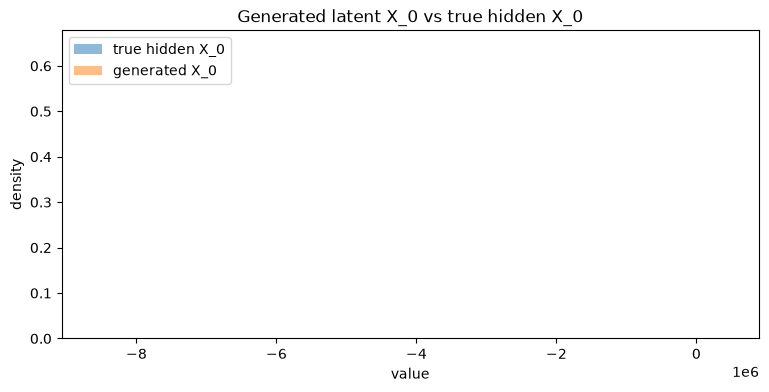

In [44]:

x0_gen, z0_gen, trajectory = sample_hidden_x_from_z_ddpm(model, n_samples=30000)

x0_real, z0_real = sample_joint_data(30000, data=data)
x0_real = x0_real.detach().cpu()
z0_real = z0_real.detach().cpu()

plt.figure(figsize=(9, 4))
plt.hist(x0_real.numpy(), bins=150, density=True, alpha=0.5, label="true hidden X_0")
plt.hist(x0_gen.numpy(), bins=150, density=True, alpha=0.5, label="generated X_0")
plt.title("Generated latent X_0 vs true hidden X_0")
plt.xlabel("value")
plt.ylabel("density")
plt.legend()
plt.show()



